In [54]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [55]:
img = cv2.imread('lenna.png', cv2.IMREAD_GRAYSCALE)

# Size of the Image

In [56]:
h, w = img.shape
print("Height:", h)
print("Width:", w)
size = h * w
print(f"Size of the image: {size} pixels")

Height: 256
Width: 256
Size of the image: 65536 pixels


# Min Max Contrast Stretching

(-0.5, 255.5, 255.5, -0.5)

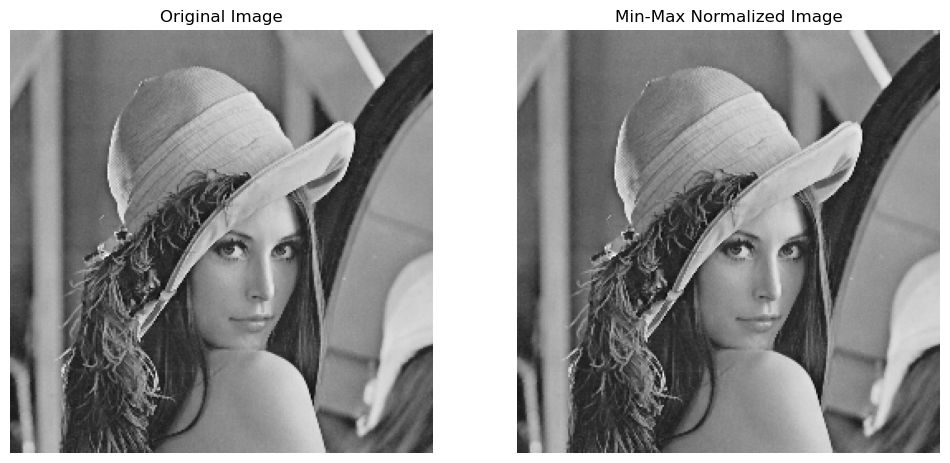

In [57]:
r_min = np.min(img)
r_max = np.max(img)
min_max_scaled = ((img - r_min) / (r_max - r_min)) * 255
min_max_scaled = np.array(min_max_scaled, dtype=np.uint8)

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(min_max_scaled, cmap='gray')
plt.title('Min-Max Normalized Image')
plt.axis('off')

# Laplacian Response of the Min Max Contrast Stretched Image

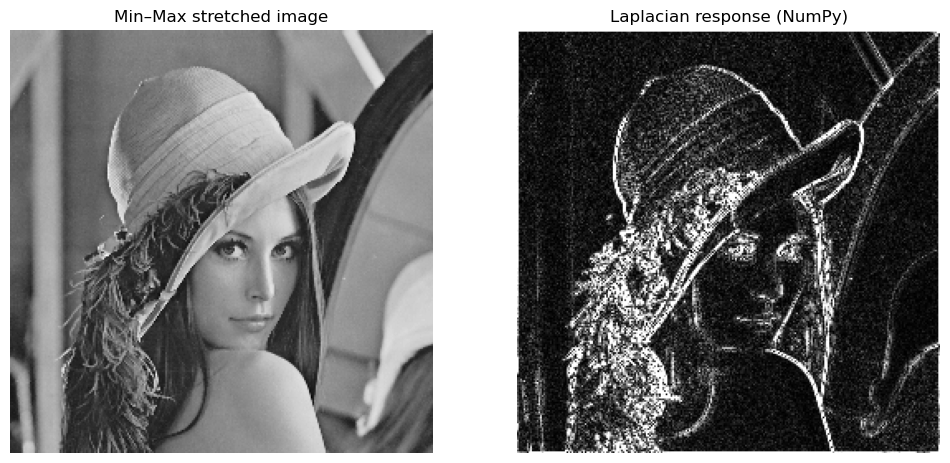

In [58]:
img_u8 = min_max_scaled
img_f  = img_u8.astype(np.float32)

pad = np.pad(img_f, pad_width=1)

center = pad[1:-1, 1:-1]
lap = (
    pad[:-2, :-2] + pad[:-2, 1:-1] + pad[:-2, 2:] +   
    pad[1:-1, :-2]                     + pad[1:-1, 2:] +   
    pad[2:, :-2]  + pad[2:, 1:-1]  + pad[2:, 2:]       
) - 8.0 * center

lap_abs = np.rint(np.abs(lap))           # abs + round
lap_abs = np.clip(lap_abs, 0, 255).astype(np.uint8)


plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(img_u8, cmap='gray')
plt.title("Min–Max stretched image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(lap_abs, cmap='gray')
plt.title("Laplacian response (NumPy)")
plt.axis("off")

plt.show()